In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("sales_prediction.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [3]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Train the model here:


In [5]:
X = data.drop(columns=['Item_Outlet_Sales'])
y = data['Item_Outlet_Sales']
SEED = 42 # for reproducibility

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5966, 11), (2557, 11), (5966,), (2557,))

In [7]:
X_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Fruits and Vegetables,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Breads,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Snack Foods,222.6088,OUT045,2002,NaN,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Frozen Foods,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


In [8]:
y_train.head()

1921     117.8466
655     1230.3984
2229    4933.5780
2537    1789.6704
3528    3872.9586
Name: Item_Outlet_Sales, dtype: float64

In [9]:
# make a copy of data for explorations/modifications
X_train_copy = X_train.copy()


In [10]:
X_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5966 entries, 1921 to 7270
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5966 non-null   object 
 1   Item_Weight                4943 non-null   float64
 2   Item_Fat_Content           5966 non-null   object 
 3   Item_Visibility            5966 non-null   float64
 4   Item_Type                  5966 non-null   object 
 5   Item_MRP                   5966 non-null   float64
 6   Outlet_Identifier          5966 non-null   object 
 7   Outlet_Establishment_Year  5966 non-null   int64  
 8   Outlet_Size                4276 non-null   object 
 9   Outlet_Location_Type       5966 non-null   object 
 10  Outlet_Type                5966 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 559.3+ KB


In [11]:
X_train_copy.isnull().sum()

Item_Identifier                 0
Item_Weight                  1023
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1690
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [12]:
num_data = X_train_copy.select_dtypes(exclude='object') #selecting numerical columns only
num_data.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
1921,7.72,0.147904,116.6466,1998
655,19.75,0.014301,103.0332,1997
2229,NaN,0.054221,129.1310,1985
2537,19.35,0.118342,222.6088,2002
3528,18.35,0.092150,184.8266,1987


In [13]:
num_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4943.000000,5966.000000,5966.000000,5966.000000
mean,12.937193,0.065821,141.814242,1997.867248
std,4.630433,0.051093,62.627609,8.385023
min,4.555000,0.000000,31.290000,1985.000000
25%,8.895000,0.026982,94.144250,1987.000000
50%,12.650000,0.053923,143.879900,1999.000000
75%,17.000000,0.094350,186.621400,2004.000000
max,21.350000,0.328391,266.888400,2009.000000


In [14]:
num_data.isnull().sum()

Item_Weight                  1023
Item_Visibility                 0
Item_MRP                        0
Outlet_Establishment_Year       0
dtype: int64

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: ylabel='Item_Weight'>

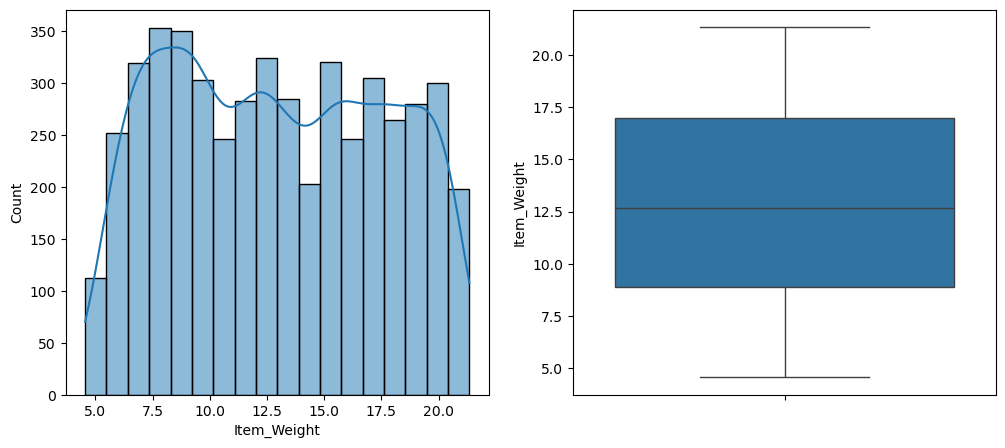

In [16]:
fig, axs = plt.subplots(1,2, figsize=(12,5)) # 1,2 means 1 row and 2 columns

sns.histplot(data = X_train_copy, x='Item_Weight', kde=True, ax=axs[0]) # ax=axs[0] means plot this graph on the first subplot
sns.boxplot(data = X_train_copy, y='Item_Weight', ax=axs[1]) # ax=axs[1] means plot this graph on the second subplot

In [17]:
def visualize_numerical_data(data, column):
    fig, axs = plt.subplots(1,2, figsize=(12,5)) # 1,2 means 1 row and 2 columns

    sns.histplot(data = data, x=column, kde=True, ax=axs[0]) # ax=axs[0] means plot this graph on the first subplot
    sns.boxplot(data = data, y=column, ax=axs[1]) # ax=axs[1] means plot this graph on the second subplot

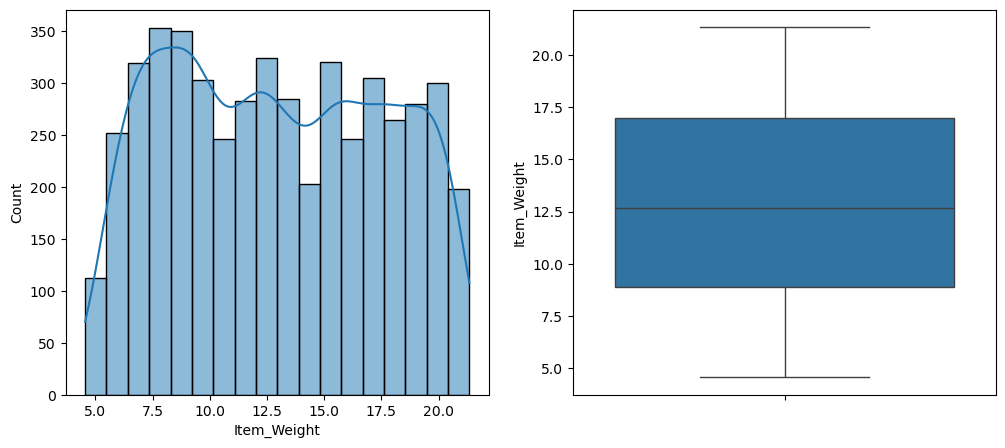

In [18]:
visualize_numerical_data(X_train_copy, 'Item_Weight')

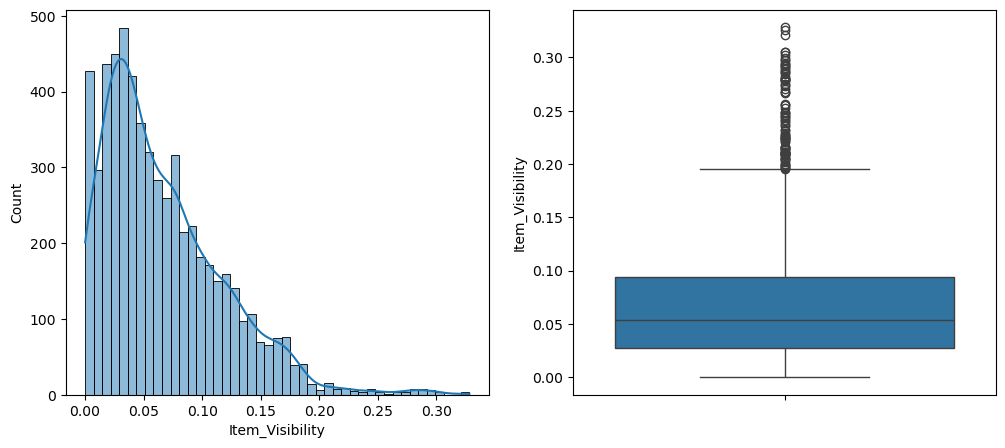

In [19]:
visualize_numerical_data(X_train_copy, 'Item_Visibility')

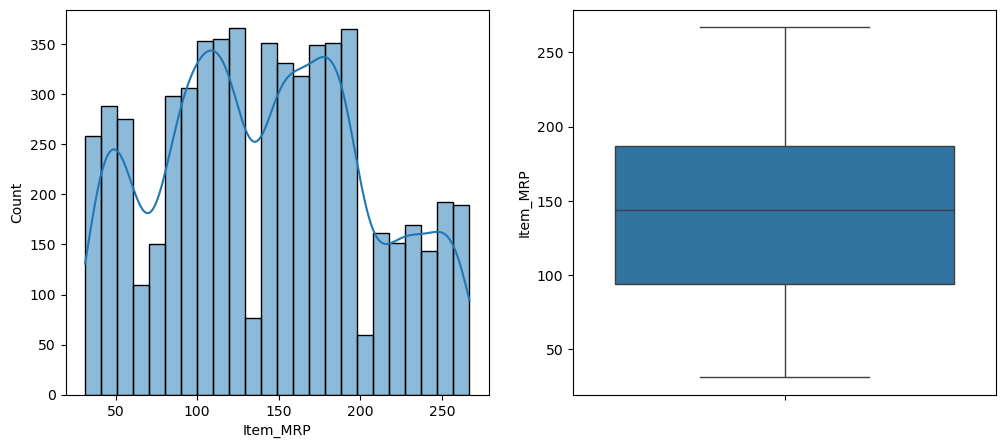

In [20]:
visualize_numerical_data(X_train_copy, 'Item_MRP')

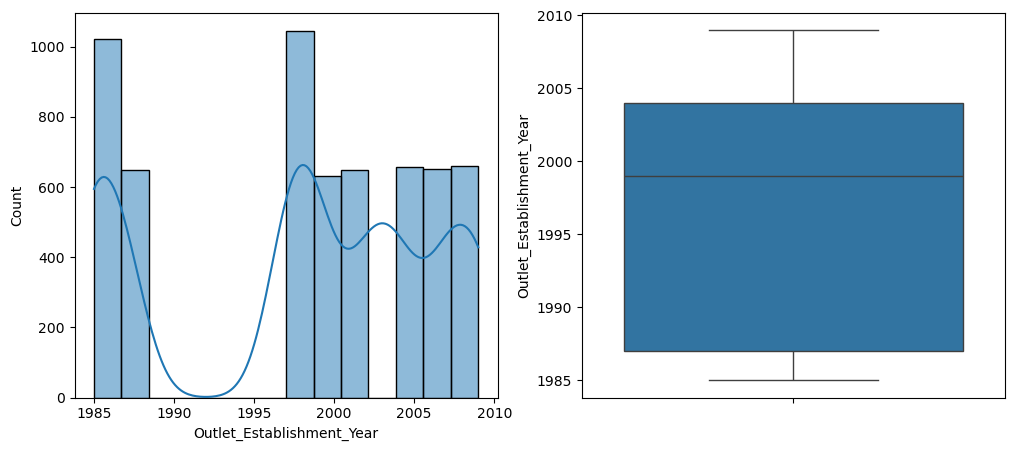

In [21]:
visualize_numerical_data(X_train_copy, 'Outlet_Establishment_Year')

<Axes: xlabel='Outlet_Establishment_Year', ylabel='count'>

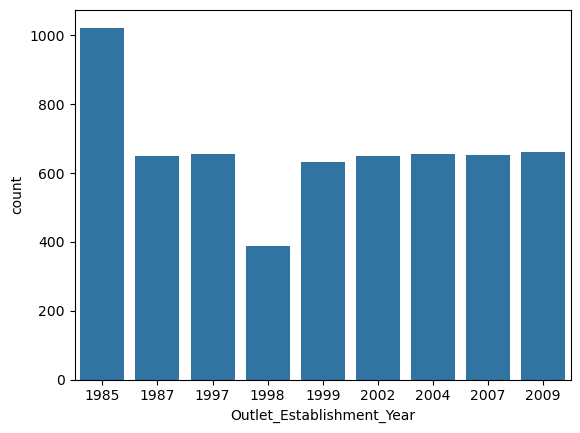

In [22]:
sns.countplot(data=X_train_copy, x='Outlet_Establishment_Year')

In [23]:
cat_features = X_train_copy.select_dtypes(include='object') # selecting categorical columns only
cat_features.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,Regular,Fruits and Vegetables,OUT010,NaN,Tier 3,Grocery Store
655,NCJ42,Low Fat,Household,OUT046,Small,Tier 1,Supermarket Type1
2229,FDY47,Regular,Breads,OUT027,Medium,Tier 3,Supermarket Type3
2537,FDN45,Low Fat,Snack Foods,OUT045,NaN,Tier 2,Supermarket Type1
3528,FDY16,Regular,Frozen Foods,OUT013,High,Tier 3,Supermarket Type1


In [24]:
cat_features.describe()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,5966,5966,5966,5966,4276,5966,5966
unique,1543,5,16,10,3,3,4
top,FDF52,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,9,3535,905,668,1960,2367,3893


In [25]:
cat_features.isnull().sum()

Item_Identifier            0
Item_Fat_Content           0
Item_Type                  0
Outlet_Identifier          0
Outlet_Size             1690
Outlet_Location_Type       0
Outlet_Type                0
dtype: int64

In [26]:
cat_features['Item_Identifier'].value_counts()

Item_Identifier
FDF52    9
NCI54    9
DRJ24    8
FDT07    8
FDV60    8
        ..
FDR16    1
FDY19    1
FDV27    1
FDN51    1
FDG28    1
Name: count, Length: 1543, dtype: int64

In [27]:
cat_features['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    3535
Regular    2027
LF          243
low fat      82
reg          79
Name: count, dtype: int64

In [28]:
cat_features['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    905
Snack Foods              835
Household                648
Frozen Foods             591
Dairy                    474
Canned                   450
Baking Goods             438
Health and Hygiene       365
Soft Drinks              305
Meat                     275
Hard Drinks              162
Breads                   159
Others                   124
Starchy Foods            116
Breakfast                 80
Seafood                   39
Name: count, dtype: int64

In [29]:
cat_features['Outlet_Identifier'].value_counts()

Outlet_Identifier
OUT027    668
OUT018    661
OUT035    656
OUT046    656
OUT017    652
OUT013    649
OUT045    649
OUT049    631
OUT010    389
OUT019    355
Name: count, dtype: int64

In [30]:
cat_features['Outlet_Size'].value_counts()

Outlet_Size
Medium    1960
Small     1667
High       649
Name: count, dtype: int64

In [31]:
cat_features['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    2367
Tier 2    1957
Tier 1    1642
Name: count, dtype: int64

In [32]:
cat_features['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    3893
Grocery Store         744
Supermarket Type3     668
Supermarket Type2     661
Name: count, dtype: int64

Data Wrangling and Feature Engineering:

# 40 Mins

## TEst:


In [33]:
X_train_copy.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Fruits and Vegetables,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Breads,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Snack Foods,222.6088,OUT045,2002,NaN,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Frozen Foods,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


In [34]:
X_train_copy2 = X_train_copy.copy()

In [35]:
X_train_copy2.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Fruits and Vegetables,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Breads,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Snack Foods,222.6088,OUT045,2002,NaN,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Frozen Foods,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


In [36]:
X_train_copy2.select_dtypes(exclude='object').head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
1921,7.72,0.147904,116.6466,1998
655,19.75,0.014301,103.0332,1997
2229,NaN,0.054221,129.1310,1985
2537,19.35,0.118342,222.6088,2002
3528,18.35,0.092150,184.8266,1987


In [37]:
X_train_copy2.select_dtypes(exclude='object').isnull().sum()

Item_Weight                  1023
Item_Visibility                 0
Item_MRP                        0
Outlet_Establishment_Year       0
dtype: int64

<Axes: xlabel='Item_Weight', ylabel='Count'>

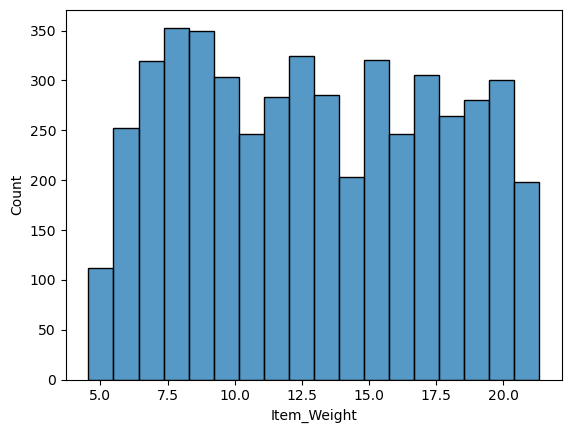

In [75]:
sns.histplot(data=X_train_copy2, x='Item_Weight')
# data is not symmetric, so can use Median to fill na.

In [39]:
X_train_copy2['Item_Weight'].fillna(X_train_copy2['Item_Weight'].median(), inplace=True)

C:\Users\Asrar\AppData\Local\Temp\ipykernel_26044\437087683.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_copy2['Item_Weight'].fillna(X_train_copy2['Item_Weight'].median(), inplace=True)


In [40]:
X_train_copy2.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1690
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [41]:
X_train_copy2 = X_train_copy2.select_dtypes(exclude='object')

In [42]:
X_train_copy2.head(10)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
1921,7.720,0.147904,116.6466,1998
655,19.750,0.014301,103.0332,1997
2229,12.650,0.054221,129.1310,1985
2537,19.350,0.118342,222.6088,2002
3528,18.350,0.092150,184.8266,1987
6101,21.250,0.155695,177.6370,2002
2540,8.615,0.116152,94.1436,1987
3166,8.800,0.071370,209.1612,1987
7687,6.150,0.046262,97.8384,2004
2457,12.100,0.114874,221.4114,1997


In [43]:
from sklearn.ensemble import RandomForestRegressor

In [44]:
y_train.head()

1921     117.8466
655     1230.3984
2229    4933.5780
2537    1789.6704
3528    3872.9586
Name: Item_Outlet_Sales, dtype: float64

In [45]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf.fit(X_train_copy2, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

In [46]:
# Predict using Random Forest:

# Make X_test same as training data
X_test_copy = X_test.copy()

# Keep only numeric columns
X_test_copy = X_test_copy.select_dtypes(exclude='object')

# Predict
y_pred = rf.predict(X_test_copy)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


RMSE: 1320.5341433290337
MAE : 925.9187205554397
R2  : 0.3774314697040969


In [76]:
X_test_copy.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
7503,14.300,0.026300,79.4302,1987
2957,7.930,0.071136,42.7086,1997
7031,14.500,0.041313,42.0454,1999
1084,NaN,0.044767,173.7054,1985
856,10.195,0.012456,197.5110,2004


In [77]:
X_test_copy2.head()

NameError: name 'X_test_copy2' is not defined

### Gradient Boosting & XGBoost:

#### Trying two new model for accuracy check.

In [78]:
from sklearn.ensemble import GradientBoostingRegressor  

gbr = GradientBoostingRegressor(n_estimators= 200,learning_rate=0.05,max_depth=4,random_state=42)

# Train
gbr.fit(X_train_copy2, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=200,
                          random_state=42)

In [80]:
X_test_copy.isnull().sum()

Item_Weight                  440
Item_Visibility                0
Item_MRP                       0
Outlet_Establishment_Year      0
dtype: int64

In [81]:
X_test_copy["Item_Weight"].fillna(X_train_copy2['Item_Weight'].median(), inplace=True)

C:\Users\Asrar\AppData\Local\Temp\ipykernel_26044\4011782551.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_copy["Item_Weight"].fillna(X_train_copy2['Item_Weight'].median(), inplace=True)


In [84]:
X_test_copy.isnull().sum() 
# no nulls, did this cause :
# ValueError: Input X contains NaN.
# GradientBoostingRegressor does not accept missing values encoded as NaN natively.

Item_Weight                  0
Item_Visibility              0
Item_MRP                     0
Outlet_Establishment_Year    0
dtype: int64

In [85]:
# Predict
y_pred = gbr.predict(X_test_copy)

In [86]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 1249.4963919408588
MAE : 885.153236921102
R2  : 0.44261162397475073


### Now XGBoost: 

In [87]:
from xgboost import XGBRegressor

In [88]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_copy2, y_train)

y_pred = xgb.predict(X_test_copy)


In [89]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


RMSE: 1312.930127890168
MAE : 927.4480403950888
R2  : 0.3845806840026804


#### Low Accuracy in all models cause not using categorical columns as features, will do in next phase: 

### Categorical Columns:

In [47]:
X_train_copy.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Fruits and Vegetables,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Breads,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Snack Foods,222.6088,OUT045,2002,NaN,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Frozen Foods,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


In [48]:
X_test_copy.select_dtypes(exclude='object')

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
7503,14.300,0.026300,79.4302,1987
2957,7.930,0.071136,42.7086,1997
7031,14.500,0.041313,42.0454,1999
1084,NaN,0.044767,173.7054,1985
856,10.195,0.012456,197.5110,2004
...,...,...,...,...
443,12.350,0.164197,120.5124,1999
777,5.460,0.032171,184.8240,2004
1119,18.350,0.148939,191.9504,1998
3209,10.000,0.037978,128.6994,2007


In [49]:
X_train_copy.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Fruits and Vegetables,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Breads,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Snack Foods,222.6088,OUT045,2002,NaN,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Frozen Foods,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


In [50]:
X_train_copy.isnull().sum()

Item_Identifier                 0
Item_Weight                  1023
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1690
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

### Null Values in --Item_Weight-- column:

In [51]:
X_train_copy[["Item_Weight"]]

,Item_Weight
1921,7.720
655,19.750
2229,NaN
2537,19.350
3528,18.350
...,...
5734,9.395
5191,15.600
5390,17.600
860,20.350


In [52]:
X_train_copy["Item_Weight"][X_train_copy["Item_Weight"].isna()]

2229   NaN
6699   NaN
7970   NaN
6606   NaN
5425   NaN
        ..
7734   NaN
3005   NaN
4555   NaN
2433   NaN
5578   NaN
Name: Item_Weight, Length: 1023, dtype: float64

In [53]:
print(X_train_copy["Item_Weight"].mean())
print(X_train_copy["Item_Weight"].median())

12.937193000202306
12.65


<Axes: xlabel='Item_Weight', ylabel='Count'>

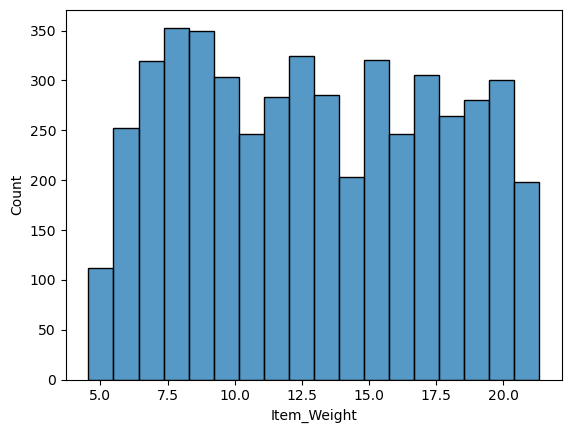

In [54]:
sns.histplot(data=X_train_copy, x='Item_Weight')

In [55]:
X_train_copy['Item_Weight'].mean()

np.float64(12.937193000202306)

### Null Values in --Outlet_Size-- column:

In [56]:
X_train_copy[["Outlet_Size"]]

,Outlet_Size
1921,NaN
655,Small
2229,Medium
2537,NaN
3528,High
...,...
5734,NaN
5191,NaN
5390,NaN
860,NaN


In [57]:
X_train_copy["Outlet_Size"][X_train_copy["Outlet_Size"].isna()]

1921    NaN
2537    NaN
6101    NaN
4423    NaN
558     NaN
       ... 
1685    NaN
5734    NaN
5191    NaN
5390    NaN
860     NaN
Name: Outlet_Size, Length: 1690, dtype: object

<Axes: xlabel='Outlet_Size', ylabel='Count'>

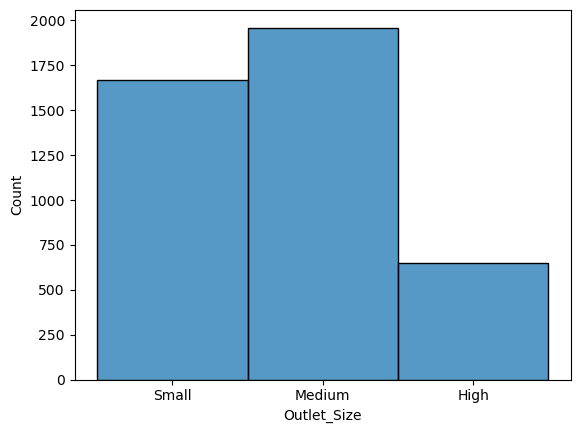

In [58]:
sns.histplot(data=X_train_copy, x='Outlet_Size')

In [59]:
X_train_copy["Outlet_Size"].mode()[0]

'Medium'

### Filled NaN values using column mode

In [60]:
X_train_copy["Outlet_Size"] = X_train_copy["Outlet_Size"].fillna(X_train_copy["Outlet_Size"].mode()[0])

In [61]:
X_train_copy.isnull().sum() 

Item_Identifier                 0
Item_Weight                  1023
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [62]:
X_train_copy[["Item_Weight"]]

,Item_Weight
1921,7.720
655,19.750
2229,NaN
2537,19.350
3528,18.350
...,...
5734,9.395
5191,15.600
5390,17.600
860,20.350


In [63]:
X_train_copy.select_dtypes(exclude=['float64','int64']).isnull().sum()

Item_Identifier         0
Item_Fat_Content        0
Item_Type               0
Outlet_Identifier       0
Outlet_Size             0
Outlet_Location_Type    0
Outlet_Type             0
dtype: int64

In [64]:
X_train_copy.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
dtype: object

In [65]:
X_train_copy["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    3535
Regular    2027
LF          243
low fat      82
reg          79
Name: count, dtype: int64

In [66]:
X_train_copy["Item_Fat_Content"] = X_train_copy["Item_Fat_Content"].replace({"LF":"Low Fat", "low fat":"Low Fat", "reg":"Regular"})

In [67]:
X_train_copy["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    3860
Regular    2106
Name: count, dtype: int64

In [90]:
X_train_copy.loc[
    (X_train_copy["Item_Identifier"].str[:2] == "NC") &
    (X_train_copy["Item_Fat_Content"] == "Low Fat")
]


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
655,NCJ42,19.750,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
4423,NCV05,10.100,Low Fat,0.030270,Health and Hygiene,152.4656,OUT045,2002,Medium,Tier 2,Supermarket Type1
907,NCA05,20.750,Low Fat,0.025273,Health and Hygiene,146.6734,OUT017,2007,Medium,Tier 2,Supermarket Type1
7021,NCL19,15.350,Low Fat,0.015676,Others,144.0470,OUT046,1997,Small,Tier 1,Supermarket Type1
6074,NCQ30,7.725,Low Fat,0.029117,Household,123.0414,OUT049,1999,Medium,Tier 1,Supermarket Type1
...,...,...,...,...,...,...,...,...,...,...,...
8322,NCE42,21.100,Low Fat,0.010602,Household,235.3958,OUT046,1997,Small,Tier 1,Supermarket Type1
466,NCS54,13.600,Low Fat,0.009985,Household,175.4370,OUT013,1987,High,Tier 3,Supermarket Type1
6265,NCW41,18.000,Low Fat,0.015450,Health and Hygiene,158.9604,OUT046,1997,Small,Tier 1,Supermarket Type1
5390,NCQ53,17.600,Low Fat,0.018944,Health and Hygiene,237.3590,OUT045,2002,Medium,Tier 2,Supermarket Type1


In [69]:
X_train_copy.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Fruits and Vegetables,116.6466,OUT010,1998,Medium,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Breads,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Snack Foods,222.6088,OUT045,2002,Medium,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Frozen Foods,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


### SIde Note:
#### For classification, use accuracy, precision, recall, and F1-score.
#### For regression, use MAE, RMSE, and R².

In [92]:
X_train_copy.isna().sum()

Item_Identifier                 0
Item_Weight                  1023
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [95]:
X_train_copy["Item_Weight"].fillna(X_train_copy["Item_Weight"].median(),inplace=True)

C:\Users\Asrar\AppData\Local\Temp\ipykernel_26044\87460993.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_copy["Item_Weight"].fillna(X_train_copy["Item_Weight"].median(),inplace=True)


In [97]:
X_train_copy.isna().sum() # nulls in dataset handled.

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

In [101]:
X_train_copy.select_dtypes(include = "object")

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,Regular,Fruits and Vegetables,OUT010,Medium,Tier 3,Grocery Store
655,NCJ42,Low Fat,Household,OUT046,Small,Tier 1,Supermarket Type1
2229,FDY47,Regular,Breads,OUT027,Medium,Tier 3,Supermarket Type3
2537,FDN45,Low Fat,Snack Foods,OUT045,Medium,Tier 2,Supermarket Type1
3528,FDY16,Regular,Frozen Foods,OUT013,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...
5734,FDY08,Regular,Fruits and Vegetables,OUT010,Medium,Tier 3,Grocery Store
5191,FDC41,Low Fat,Frozen Foods,OUT017,Medium,Tier 2,Supermarket Type1
5390,NCQ53,Low Fat,Health and Hygiene,OUT045,Medium,Tier 2,Supermarket Type1
860,FDL46,Low Fat,Snack Foods,OUT017,Medium,Tier 2,Supermarket Type1


In [127]:
data_copy = data.copy()

In [128]:
data_copy.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [129]:
data_copy.duplicated().sum()

np.int64(0)

In [130]:
data_copy["Item_Fat_Content"].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [131]:
data_copy["Item_Type"].unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [132]:
data_copy["Outlet_Identifier"].unique()

array(['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027', 'OUT045',
       'OUT017', 'OUT046', 'OUT035', 'OUT019'], dtype=object)

In [133]:
data_copy["Outlet_Establishment_Year"].unique()

array([1999, 2009, 1998, 1987, 1985, 2002, 2007, 1997, 2004])

In [134]:
data_copy["Outlet_Size"].unique()

array(['Medium', nan, 'High', 'Small'], dtype=object)

In [135]:
data_copy["Outlet_Location_Type"].unique()

array(['Tier 1', 'Tier 3', 'Tier 2'], dtype=object)

In [136]:
data_copy["Outlet_Type"].unique()

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

### standardize: Item_Fat_Content 

In [137]:
data_copy["Item_Fat_Content"].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [138]:
data_copy["Item_Fat_Content"].replace({"LF":"Low Fat", "low fat":"Low Fat", "reg":"Regular"}, inplace=True)

C:\Users\Asrar\AppData\Local\Temp\ipykernel_26044\3797283410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_copy["Item_Fat_Content"].replace({"LF":"Low Fat", "low fat":"Low Fat", "reg":"Regular"}, inplace=True)


In [139]:
data_copy["Item_Fat_Content"].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [142]:
data_copy["Item_Weight"].fillna(data_copy["Item_Weight"].median(), inplace= True)

In [148]:
data_copy["Outlet_Size"].fillna(data_copy["Outlet_Size"].mode()[0], inplace= True)

C:\Users\Asrar\AppData\Local\Temp\ipykernel_26044\1755587840.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_copy["Outlet_Size"].fillna(data_copy["Outlet_Size"].mode()[0], inplace= True)


In [150]:
data_copy.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [185]:
data["Item_Type"].dropna().unique().tolist()

['Dairy',
 'Soft Drinks',
 'Meat',
 'Fruits and Vegetables',
 'Household',
 'Baking Goods',
 'Snack Foods',
 'Frozen Foods',
 'Breakfast',
 'Health and Hygiene',
 'Hard Drinks',
 'Canned',
 'Breads',
 'Starchy Foods',
 'Others',
 'Seafood']

#### Using One-Hot Encoding on Categorical Columns:  

In [151]:
X = data_copy.drop(columns="Item_Outlet_Sales")
y = data_copy["Item_Outlet_Sales"]

In [153]:
X_encoded = pd.get_dummies(X, drop_first=True) 

In [154]:
print(X.shape)

(8523, 11)


In [155]:
print(X_encoded.shape)

(8523, 1594)


#### Train Test Split:

In [156]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X_encoded,y,test_size=0.3,random_state=42) 

In [157]:
from xgboost import XGBRegressor

In [158]:
xgb = XGBRegressor(
    n_estimators=500,      # Number of trees
    learning_rate=0.05,   # How fast model learns
    max_depth=6,          # Tree depth
    subsample=0.8,        # Use 80% data per tree
    colsample_bytree=0.8, # Use 80% features per tree
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

In [163]:
#tuned:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)


In [164]:
xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=-1, num_parallel_tree=None, ...)

In [165]:
y_pred = xgb.predict(X_test)


In [166]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


RMSE: 1090.8669157623688
MAE : 762.2247408189006
R2  : 0.5751540957590547


In [167]:
import joblib

In [168]:
joblib.dump(xgb, "sales_model.pkl")

['sales_model.pkl']

In [169]:
joblib.dump(X_encoded.columns, "model_columns.pkl")

['model_columns.pkl']